In [4]:
!pip install xgboost --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
df = pd.read_csv('features.csv')
X = df.drop(columns=['Global_active_power', 'datetime'])
y = df['Global_active_power']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [10]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [11]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

In [12]:
evals_result = {}  # Dictionary to store evaluation results
num_rounds = 100   #Number of boosting rounds (training time/epoch)

model = xgb.train(params,dtrain,num_boost_round=num_rounds,
    evals=[(dtrain, 'train'), (dtest, 'test')],evals_result=evals_result,verbose_eval=10)  # verbose_eval=10 means Print evaluation every 10 rounds

[0]	train-rmse:0.98408	test-rmse:0.81059
[10]	train-rmse:0.34423	test-rmse:0.28115
[20]	train-rmse:0.12154	test-rmse:0.09802
[30]	train-rmse:0.04486	test-rmse:0.03556
[40]	train-rmse:0.02032	test-rmse:0.01650
[50]	train-rmse:0.01379	test-rmse:0.01202
[60]	train-rmse:0.01188	test-rmse:0.01067
[70]	train-rmse:0.01119	test-rmse:0.01018
[80]	train-rmse:0.01088	test-rmse:0.00998
[90]	train-rmse:0.01054	test-rmse:0.00976
[99]	train-rmse:0.01034	test-rmse:0.00964


In [13]:
model.save_model('xgb_energy_model.json')

RMSE: 0.010
Test RMSE: 0.0096


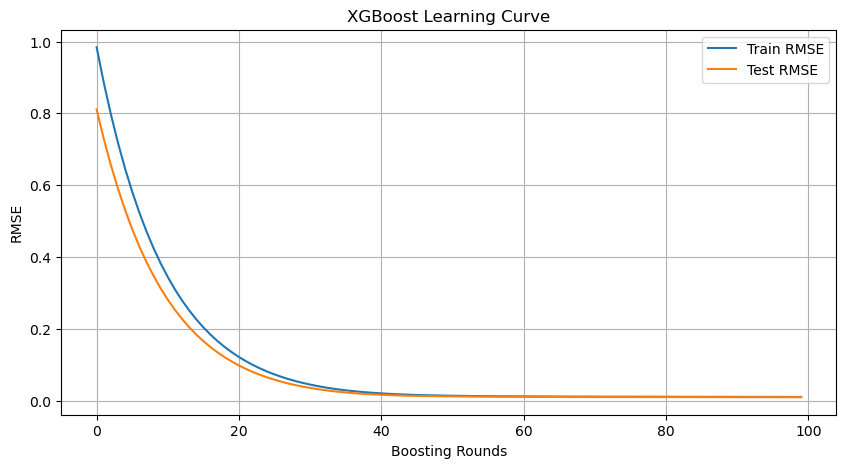

In [17]:
y_pred = model.predict(dtest)
y_true = dtest.get_label()  # ✅ Define the true labels



rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f'RMSE: {rmse:.3f}')
print(f"Test RMSE: {rmse:.4f}")

# 5. Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(evals_result['train']['rmse'], label='Train RMSE')
plt.plot(evals_result['test']['rmse'], label='Test RMSE')
plt.title('XGBoost Learning Curve')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
y_pred = model.predict(dtest)


print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')
print(f"Test RMSE: {rmse:.4f}")

# 5. Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(evals_result['train']['rmse'], label='Train RMSE')
plt.plot(evals_result['test']['rmse'], label='Test RMSE')
plt.title('XGBoost Learning Curve')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'y_true' is not defined

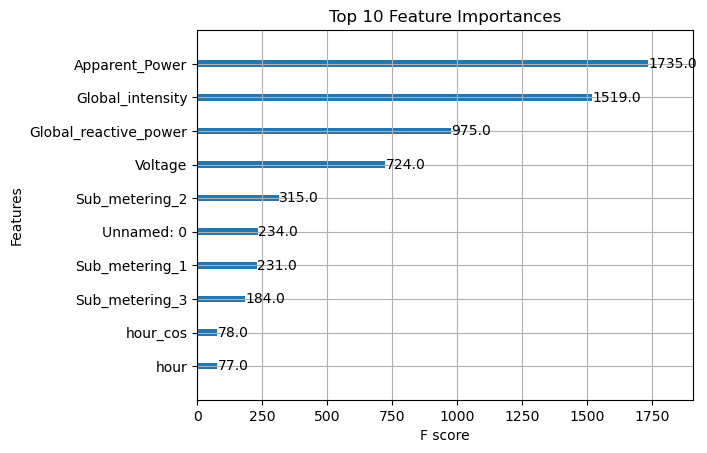

In [15]:
xgb.plot_importance(model, max_num_features=10)
plt.title('Top 10 Feature Importances')
plt.show()